# MODIS MCD19A2 — Exploratory Data Analysis

EDA over the processed GeoTIFFs in `outputs/modis/` (produced by `modis.py`):
MAIAC aerosol product, tile h29v07, clipped to the Manila-area AOI, QA-masked.

Each file is a 4-band float32 raster (`NODATA = -9999`):

| Band | Name | Content | Units |
|------|------|---------|-------|
| 1 | `AOD_047` | Aerosol optical depth @ 470 nm | unitless |
| 2 | `AOD_055` | Aerosol optical depth @ 550 nm | unitless |
| 3 | `CWV` | Column water vapour | cm |
| 4 | `QA` | QA bitmask (int stored as float) | — |

Sections 1–9: scan → overview → coverage → time series → distributions →
AOD band correlation → seasonal analysis → spatial mean map → QA breakdown.
Sections 10–15: year×month heatmaps → yearly trend → high-AOD events →
CWV & its link to AOD → dry vs wet season maps → data-gap analysis.

In [1]:
import re
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

MODIS_DIR = Path("outputs/modis")
EDA_DIR = Path("outputs/eda"); EDA_DIR.mkdir(parents=True, exist_ok=True)
NODATA = -9999.0
BAND_ORDER = ["AOD_047", "AOD_055", "CWV", "QA"]
SCIENCE_BANDS = ["AOD_047", "AOD_055", "CWV"]
AOI_BOUNDS = [120.868835, 14.316284, 121.143494, 14.781522]  # W, S, E, N (same as modis.py)
DATE_RE = re.compile(r"MODIS_(\d{8})_")

# --- palette: fixed color per band (color follows the entity, never rank) ---
C = {
    "AOD_047": "#2a78d6",   # blue
    "AOD_055": "#1baf7a",   # aqua
    "CWV":     "#4a3aa7",   # violet
    "ink":     "#0b0b0b",
    "ink2":    "#52514e",
    "muted":   "#898781",
    "grid":    "#e1e0d9",
    "baseline": "#c3c2b7",
}
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
SEQ_AQUA = LinearSegmentedColormap.from_list(
    "seq_aqua", ["#d8f3e9", "#8fdcbf", "#3fc394", "#1baf7a", "#12805a", "#0b5c40"])

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": C["baseline"],
    "axes.labelcolor": C["ink2"],
    "axes.titlecolor": C["ink"],
    "axes.grid": True,
    "grid.color": C["grid"],
    "grid.linewidth": 0.8,
    "xtick.color": C["muted"],
    "ytick.color": C["muted"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

## 1. Scan all files (single pass)

One pass over every GeoTIFF accumulates everything the rest of the notebook needs:

- per-file summary rows (valid pixel counts + band stats) → `df`
- pooled pixel values per band → `pools` (for histograms)
- matched AOD_047/AOD_055 pixel pairs → `pair_x`, `pair_y` (for the scatter)
- QA category counters → `qa_counts` (for the QA breakdown)
- AOD_047 reprojected onto a common ~1 km lat/lon grid, accumulated **per
  calendar month** → `aod_sum`, `aod_cnt` (shape `12×H×W`) — the per-file rasters
  are trimmed to valid data, so their shapes/transforms all differ and must be
  resampled onto one grid before any spatial averaging; keeping the months
  separate lets us build both the all-time and the seasonal maps from one pass

Takes a minute or two for ~1000 files.

In [2]:
files = sorted(MODIS_DIR.glob("*.tif"))
print(f"{len(files)} GeoTIFFs")

# common lat/lon grid for the spatial mean (~1 km ~= 0.009 deg)
RES = 0.009
GW = int(np.ceil((AOI_BOUNDS[2] - AOI_BOUNDS[0]) / RES))
GH = int(np.ceil((AOI_BOUNDS[3] - AOI_BOUNDS[1]) / RES))
grid_transform = from_bounds(*AOI_BOUNDS, GW, GH)
aod_sum = np.zeros((12, GH, GW), dtype="float64")   # per calendar month
aod_cnt = np.zeros((12, GH, GW), dtype="int32")

rows, pools = [], {k: [] for k in SCIENCE_BANDS}
pair_x, pair_y = [], []
qa_counts = {"kept": 0, "adjacent cloud": 0, "cloudy": 0, "fill": 0}

for path in files:
    with rasterio.open(path) as src:
        arrs = {k: src.read(i).astype("float32") for i, k in enumerate(BAND_ORDER, 1)}
        src_transform, src_crs = src.transform, src.crs

    for k in SCIENCE_BANDS:
        arrs[k][arrs[k] == NODATA] = np.nan

    row = {"date": datetime.strptime(DATE_RE.search(path.name).group(1), "%Y%m%d"),
           "file": path.name, "total_px": arrs["AOD_047"].size}
    for k in SCIENCE_BANDS:
        v = arrs[k][~np.isnan(arrs[k])]
        row[f"{k}_valid_px"] = v.size
        row[f"{k}_valid_frac"] = v.size / row["total_px"]
        row[f"{k}_mean"] = float(v.mean()) if v.size else np.nan
        row[f"{k}_p50"] = float(np.median(v)) if v.size else np.nan
        row[f"{k}_max"] = float(v.max()) if v.size else np.nan
        if v.size:
            pools[k].append(v)
    rows.append(row)

    m = ~np.isnan(arrs["AOD_047"]) & ~np.isnan(arrs["AOD_055"])
    pair_x.append(arrs["AOD_047"][m]); pair_y.append(arrs["AOD_055"][m])

    # QA categories over in-AOI pixels (same bit convention as modis.py:
    # bits 0-1 = cloud, bit 2 = adjacent cloud, 65535 = fill)
    qa = arrs["QA"][arrs["QA"] != NODATA].astype("uint16")
    fill = qa == 65535
    cloudy = ~fill & ((qa & 0b11) > 1)
    adjacent = ~fill & ~cloudy & ((qa & 0b100) != 0)
    qa_counts["fill"] += int(fill.sum())
    qa_counts["cloudy"] += int(cloudy.sum())
    qa_counts["adjacent cloud"] += int(adjacent.sum())
    qa_counts["kept"] += int((~fill & ~cloudy & ~adjacent).sum())

    # accumulate AOD_047 onto the common grid
    dst = np.full((GH, GW), np.nan, dtype="float32")
    reproject(np.nan_to_num(arrs["AOD_047"], nan=NODATA), dst,
              src_transform=src_transform, src_crs=src_crs,
              dst_transform=grid_transform, dst_crs="EPSG:4326",
              src_nodata=NODATA, dst_nodata=np.nan, resampling=Resampling.nearest)
    gm = ~np.isnan(dst)
    mi = row["date"].month - 1
    aod_sum[mi][gm] += dst[gm]; aod_cnt[mi][gm] += 1

df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
pools = {k: (np.concatenate(v) if v else np.array([], dtype="float32")) for k, v in pools.items()}
pair_x = np.concatenate(pair_x); pair_y = np.concatenate(pair_y)
df.to_csv(EDA_DIR / "modis_summary.csv", index=False)
print("scan done ->", EDA_DIR / "modis_summary.csv")

980 GeoTIFFs


scan done -> outputs\eda\modis_summary.csv


## 2. Overview

In [3]:
empty = (df["AOD_047_valid_px"] == 0).sum()
print(f"Files:            {len(df)}")
print(f"Date range:       {df['date'].min():%Y-%m-%d} -> {df['date'].max():%Y-%m-%d}")
print(f"Empty AOD files:  {empty} ({empty/len(df):.1%})")
print(f"Median coverage:  {df['AOD_047_valid_frac'].median():.1%} of AOI")
df[[f"{k}_mean" for k in SCIENCE_BANDS]].describe().round(3)

Files:            980
Date range:       2021-07-12 -> 2026-07-08
Empty AOD files:  36 (3.7%)
Median coverage:  13.0% of AOI


,AOD_047_mean,AOD_055_mean,CWV_mean
count,944.000,944.000,964.000
mean,0.330,0.242,4.739
std,0.142,0.106,1.211
min,0.000,0.000,0.892
25%,0.230,0.168,4.025
50%,0.322,0.234,4.883
75%,0.431,0.317,5.687
max,1.137,0.842,6.897


## 3. Coverage over time

How much of the AOI survives QA masking on each date. Low coverage is normal for
MAIAC over a cloudy tropical AOI — but long gaps or a trend here would matter.

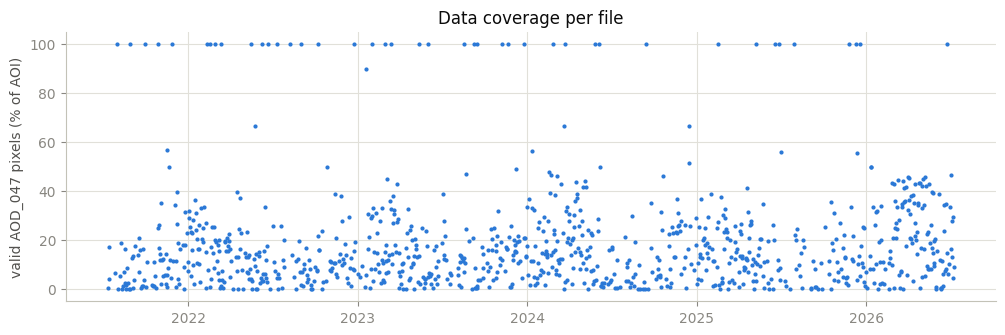

In [4]:
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(df["date"], df["AOD_047_valid_frac"] * 100, ".", ms=4, color=C["AOD_047"])
ax.set_ylabel("valid AOD_047 pixels (% of AOI)")
ax.set_title("Data coverage per file")
plt.show()

## 4. AOD time series

Daily AOI means (faint points) with monthly means (solid lines) for both AOD bands.

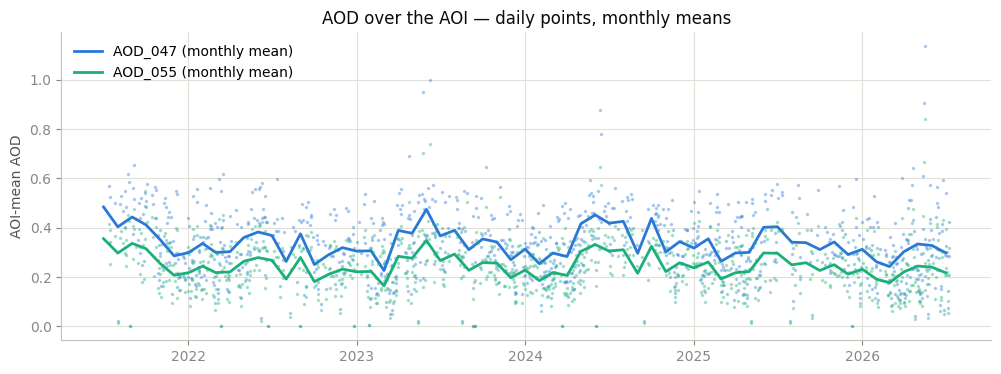

In [5]:
d = df[df["AOD_047_valid_px"] > 0].set_index("date")
monthly = d[["AOD_047_mean", "AOD_055_mean"]].resample("MS").mean()

fig, ax = plt.subplots(figsize=(12, 4))
for k in ("AOD_047", "AOD_055"):
    ax.plot(d.index, d[f"{k}_mean"], ".", ms=3, alpha=0.3, color=C[k])
    ax.plot(monthly.index, monthly[f"{k}_mean"], "-", lw=2, color=C[k],
            label=f"{k} (monthly mean)")
ax.set_ylabel("AOI-mean AOD")
ax.set_title("AOD over the AOI — daily points, monthly means")
ax.legend(frameon=False)
plt.show()

## 5. Pixel-level distributions

All valid pixels pooled across every file.

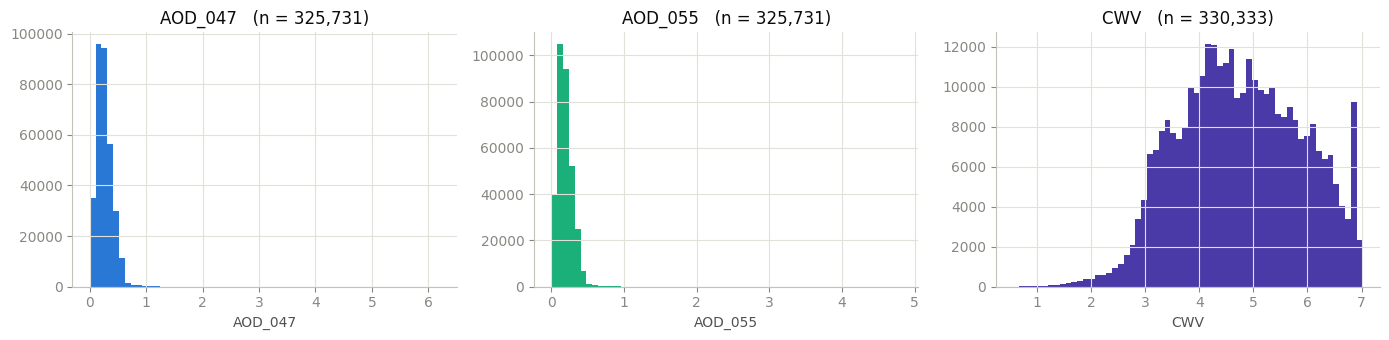

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, k in zip(axes, SCIENCE_BANDS):
    ax.hist(pools[k], bins=60, color=C[k])
    ax.set_title(f"{k}   (n = {pools[k].size:,})")
    ax.set_xlabel(k)
plt.tight_layout(); plt.show()

## 6. AOD_047 vs AOD_055

The two bands come from the same retrieval, so they should sit on a tight line
just below 1:1 (AOD decreases with wavelength). Points far off that line are
worth a second look.

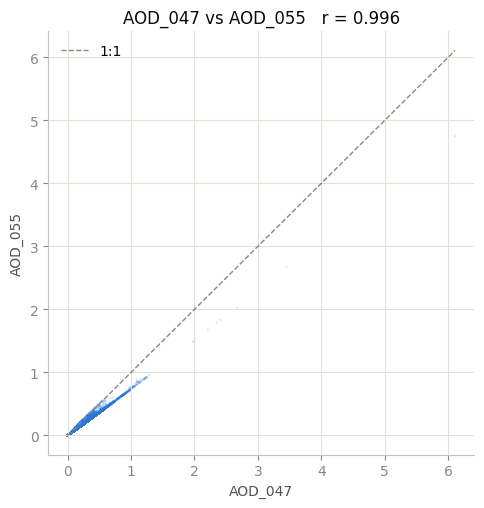

In [7]:
n = pair_x.size
if n > 50_000:
    idx = np.random.default_rng(0).choice(n, 50_000, replace=False)
    x, y = pair_x[idx], pair_y[idx]
else:
    x, y = pair_x, pair_y
r = np.corrcoef(pair_x, pair_y)[0, 1]

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(x, y, s=3, alpha=0.15, color=C["AOD_047"], edgecolors="none")
lim = float(max(x.max(), y.max()))
ax.plot([0, lim], [0, lim], "--", lw=1, color=C["muted"], label="1:1")
ax.set_xlabel("AOD_047"); ax.set_ylabel("AOD_055")
ax.set_title(f"AOD_047 vs AOD_055   r = {r:.3f}")
ax.legend(frameon=False)
plt.show()

## 7. Seasonal analysis

Left: distribution of file-mean AOD_047 by calendar month (all years pooled) —
this is where a dry-season haze peak shows up. Right: mean valid coverage by
month — the wet-season cloud cost.

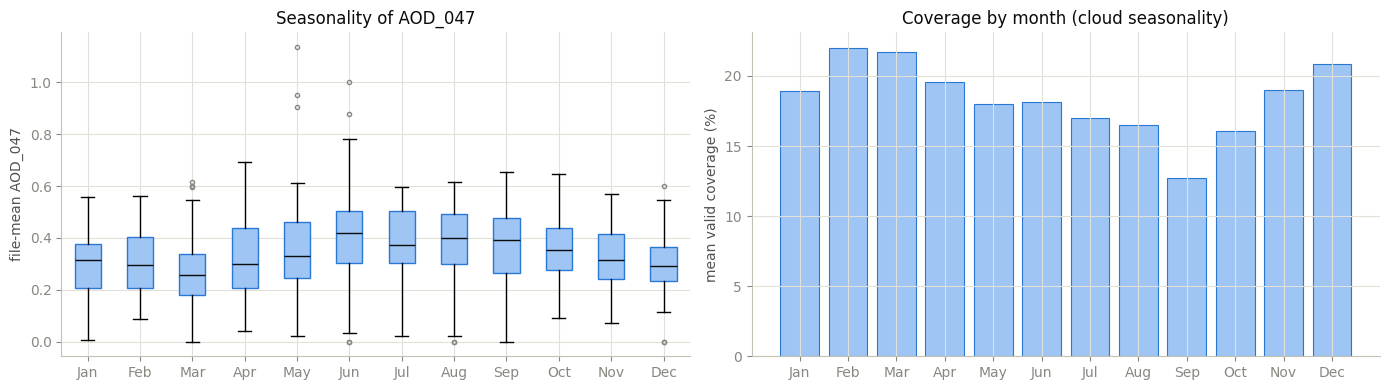

In [8]:
d = df[df["AOD_047_valid_px"] > 0].copy()
d["month"] = pd.to_datetime(d["date"]).dt.month
months = range(1, 13)
labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
bp = ax1.boxplot([d.loc[d["month"] == m, "AOD_047_mean"].dropna() for m in months],
                 tick_labels=labels, patch_artist=True,
                 medianprops=dict(color=C["ink"]),
                 flierprops=dict(ms=3, markeredgecolor=C["muted"]))
for box in bp["boxes"]:
    box.set(facecolor="#9ec5f4", edgecolor=C["AOD_047"])
ax1.set_ylabel("file-mean AOD_047")
ax1.set_title("Seasonality of AOD_047")

cov = (df.assign(month=pd.to_datetime(df["date"]).dt.month)
         .groupby("month")["AOD_047_valid_frac"].mean() * 100)
ax2.bar(labels, cov.reindex(months).values, color="#9ec5f4",
        edgecolor=C["AOD_047"], lw=0.8)
ax2.set_ylabel("mean valid coverage (%)")
ax2.set_title("Coverage by month (cloud seasonality)")
plt.tight_layout(); plt.show()

## 8. Spatial mean map

Every file's AOD_047 band resampled onto the common ~1 km lat/lon grid, then
averaged per cell. Left: the multi-year mean AOD climatology (urban Manila
should stand out). Right: how many valid observations each cell has — read the
mean map with this in hand, since thinly-observed cells are noisier.

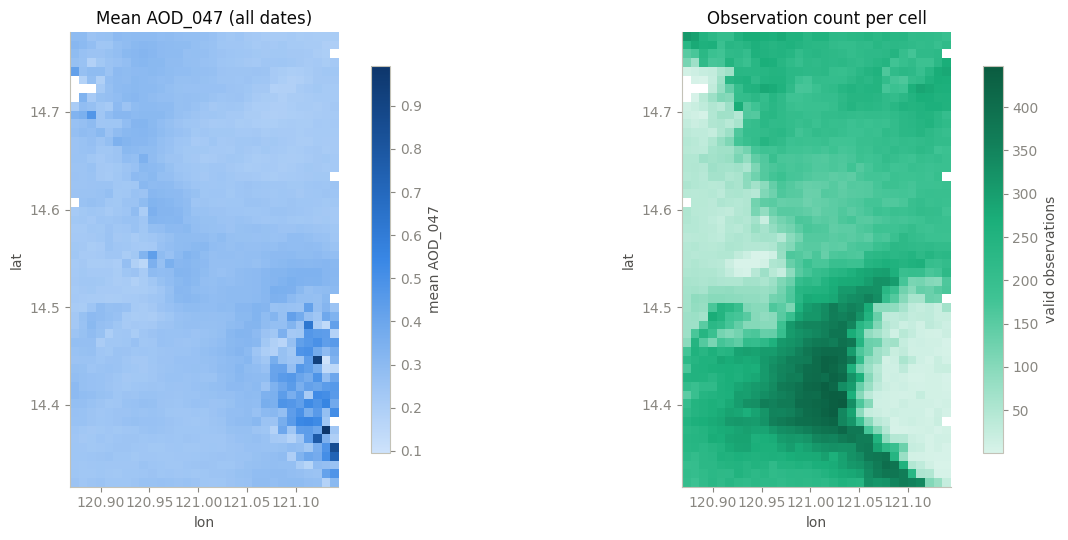

In [9]:
tot_sum, tot_cnt = aod_sum.sum(axis=0), aod_cnt.sum(axis=0)
mean_grid = np.where(tot_cnt > 0, tot_sum / np.maximum(tot_cnt, 1), np.nan)
extent = [AOI_BOUNDS[0], AOI_BOUNDS[2], AOI_BOUNDS[1], AOI_BOUNDS[3]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
im1 = ax1.imshow(mean_grid, cmap=SEQ_BLUE, extent=extent, origin="upper")
fig.colorbar(im1, ax=ax1, shrink=0.85, label="mean AOD_047")
ax1.set_title("Mean AOD_047 (all dates)")

im2 = ax2.imshow(np.where(tot_cnt > 0, tot_cnt, np.nan),
                 cmap=SEQ_AQUA, extent=extent, origin="upper")
fig.colorbar(im2, ax=ax2, shrink=0.85, label="valid observations")
ax2.set_title("Observation count per cell")

for ax in (ax1, ax2):
    ax.set_xlabel("lon"); ax.set_ylabel("lat"); ax.grid(False)
plt.tight_layout(); plt.show()

## 9. QA breakdown — why pixels get dropped

Decoded from the saved QA band using the same convention as `modis.py`
(`build_qa_mask`): bits 0–1 = cloud status (kept if ≤ 1), bit 2 = adjacent
cloud, `65535` = fill. Percentages are over all in-AOI pixels across all files.

Note "kept" means *passed the QA mask* — the AOD retrieval itself can still be
fill there, so the kept share is an upper bound on valid-AOD coverage.

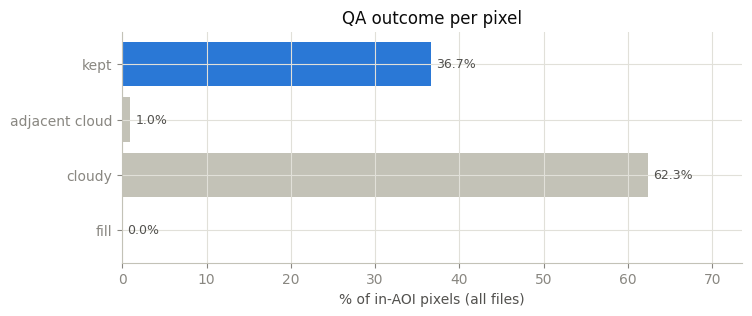

,pixels,pct
kept,446715,36.7
adjacent cloud,11682,1.0
cloudy,758922,62.3
fill,0,0.0


In [10]:
total = sum(qa_counts.values())
cats = ["kept", "adjacent cloud", "cloudy", "fill"]
fracs = [qa_counts[c] / total * 100 for c in cats]
colors = [C["AOD_047"], C["baseline"], C["baseline"], C["baseline"]]

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(cats[::-1], fracs[::-1], color=colors[::-1])
for b, f in zip(bars, fracs[::-1]):
    ax.text(b.get_width() + 0.6, b.get_y() + b.get_height() / 2, f"{f:.1f}%",
            va="center", color=C["ink2"], fontsize=9)
ax.set_xlabel("% of in-AOI pixels (all files)")
ax.set_title("QA outcome per pixel")
ax.set_xlim(0, max(fracs) * 1.18)
plt.show()

pd.Series(qa_counts, name="pixels").to_frame().assign(
    pct=lambda t: (t["pixels"] / total * 100).round(1))

## 10. Year × month heatmaps

The seasonal boxplots pool all years together; these heatmaps separate them, so
you can tell a *recurring* seasonal signal from a one-off year. Left: mean AOD.
Right: mean valid coverage — read the AOD cells against it, since a month with
5% coverage is a much noisier estimate than one with 25%.

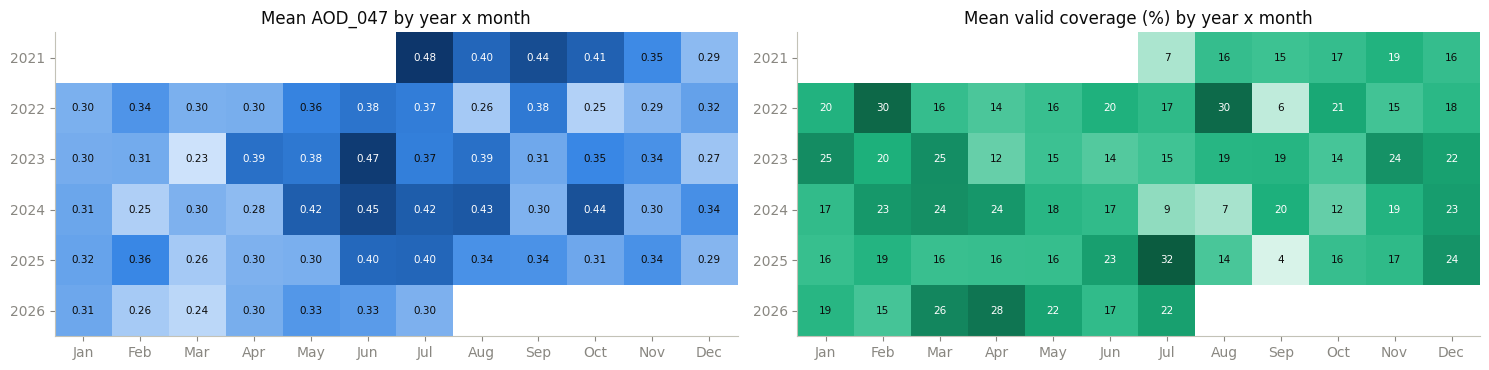

In [11]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
dt = pd.to_datetime(df["date"])
dym = df.assign(year=dt.dt.year, month=dt.dt.month)
pv_aod = (dym.pivot_table(index="year", columns="month",
                          values="AOD_047_mean", aggfunc="mean")
             .reindex(columns=range(1, 13)))
pv_cov = (dym.pivot_table(index="year", columns="month",
                          values="AOD_047_valid_frac", aggfunc="mean")
             .reindex(columns=range(1, 13)) * 100)

fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))
for ax, pv, cmap, title, fmt in [
    (axes[0], pv_aod, SEQ_BLUE, "Mean AOD_047 by year x month", "{:.2f}"),
    (axes[1], pv_cov, SEQ_AQUA, "Mean valid coverage (%) by year x month", "{:.0f}"),
]:
    ax.imshow(pv.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(12), MONTHS)
    ax.set_yticks(range(len(pv.index)), pv.index)
    vmin, vmax = np.nanmin(pv.values), np.nanmax(pv.values)
    for i in range(pv.shape[0]):
        for j in range(12):
            v = pv.values[i, j]
            if np.isnan(v):
                continue
            frac = (v - vmin) / (vmax - vmin + 1e-9)
            ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=7.5,
                    color="white" if frac > 0.55 else C["ink"])
    ax.set_title(title)
    ax.grid(False)
plt.tight_layout(); plt.show()

## 11. Year-over-year trend

Distribution of file-mean AOD_047 per year (partial years included — the tick
label shows how many files feed each box).

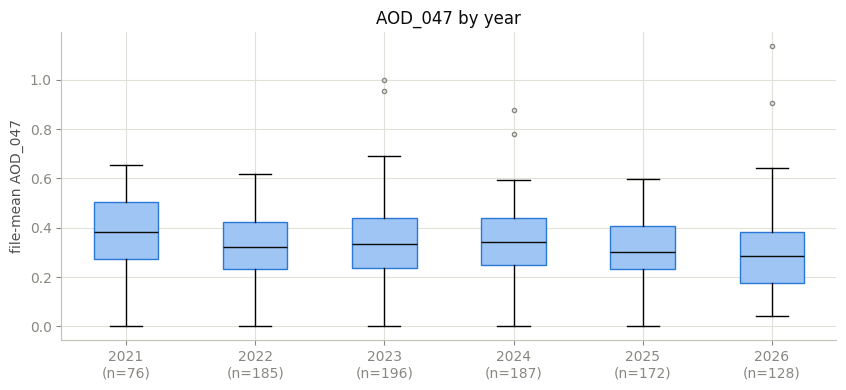

In [12]:
dy = dym[dym["AOD_047_valid_px"] > 0]
years = sorted(dy["year"].unique())
vals = [dy.loc[dy["year"] == y, "AOD_047_mean"].dropna() for y in years]

fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(vals, tick_labels=[f"{y}\n(n={len(v)})" for y, v in zip(years, vals)],
                patch_artist=True,
                medianprops=dict(color=C["ink"]),
                flierprops=dict(ms=3, markeredgecolor=C["muted"]))
for box in bp["boxes"]:
    box.set(facecolor="#9ec5f4", edgecolor=C["AOD_047"])
ax.set_ylabel("file-mean AOD_047")
ax.set_title("AOD_047 by year")
plt.show()

## 12. High-AOD event days

Days whose AOI-mean AOD_047 sits at or above the 95th percentile — candidate
haze / burning / transport events worth investigating individually. Files with
fewer than 20 valid pixels are excluded so a couple of noisy pixels can't fake
an event.

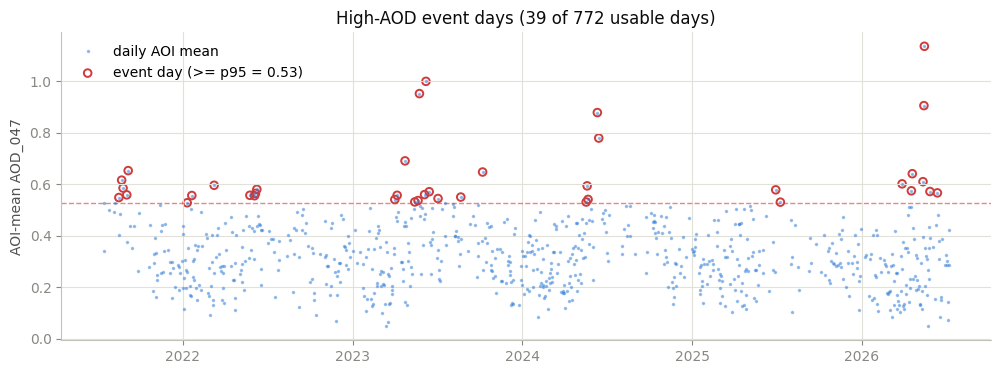

,date,AOD_047_mean,AOD_047_max,AOD_047_valid_frac,file
0,2026-05-16,1.136535,1.308,0.081255,MODIS_20260516_MCD19A2.A2026136.h29v07.061.202...
1,2023-06-08,1.000354,1.249,0.019208,MODIS_20230608_MCD19A2.A2023159.h29v07.061.202...
2,2023-05-25,0.952692,1.335,0.025692,MODIS_20230525_MCD19A2.A2023145.h29v07.061.202...
3,2026-05-15,0.906038,1.179,0.231746,MODIS_20260515_MCD19A2.A2026135.h29v07.061.202...
4,2024-06-11,0.879082,1.084,0.026558,MODIS_20240611_MCD19A2.A2024163.h29v07.061.202...
5,2024-06-14,0.780027,1.165,0.025614,MODIS_20240614_MCD19A2.A2024166.h29v07.061.202...
6,2023-04-24,0.691445,1.176,0.044335,MODIS_20230424_MCD19A2.A2023114.h29v07.061.202...
7,2021-09-05,0.653628,0.981,0.035131,MODIS_20210905_MCD19A2.A2021248.h29v07.061.202...
8,2023-10-08,0.648210,0.987,0.071736,MODIS_20231008_MCD19A2.A2023281.h29v07.061.202...
9,2026-04-20,0.641619,1.296,0.231835,MODIS_20260420_MCD19A2.A2026110.h29v07.061.202...


In [13]:
stable = df[df["AOD_047_valid_px"] >= 20].copy()
thr = stable["AOD_047_mean"].quantile(0.95)
events = stable[stable["AOD_047_mean"] >= thr].sort_values(
    "AOD_047_mean", ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(stable["date"], stable["AOD_047_mean"], ".", ms=3, alpha=0.4,
        color=C["AOD_047"], label="daily AOI mean")
ax.scatter(events["date"], events["AOD_047_mean"], s=30, facecolors="none",
           edgecolors="#d03b3b", lw=1.4,
           label=f"event day (>= p95 = {thr:.2f})")
ax.axhline(thr, color="#d03b3b", lw=1, ls="--", alpha=0.6)
ax.set_ylabel("AOI-mean AOD_047")
ax.set_title(f"High-AOD event days ({len(events)} of {len(stable)} usable days)")
ax.legend(frameon=False)
plt.show()

events.head(10)[["date", "AOD_047_mean", "AOD_047_max",
                 "AOD_047_valid_frac", "file"]].reset_index(drop=True)

## 13. Column water vapour — seasonality and its link to AOD

Left: CWV by calendar month — this should track the monsoon far more cleanly
than AOD does. Right: per-file mean AOD vs mean CWV; a positive relationship
here often reflects hygroscopic aerosol growth in humid air (or shared
seasonality), while no relationship suggests the aerosol signal is driven by
sources rather than humidity.

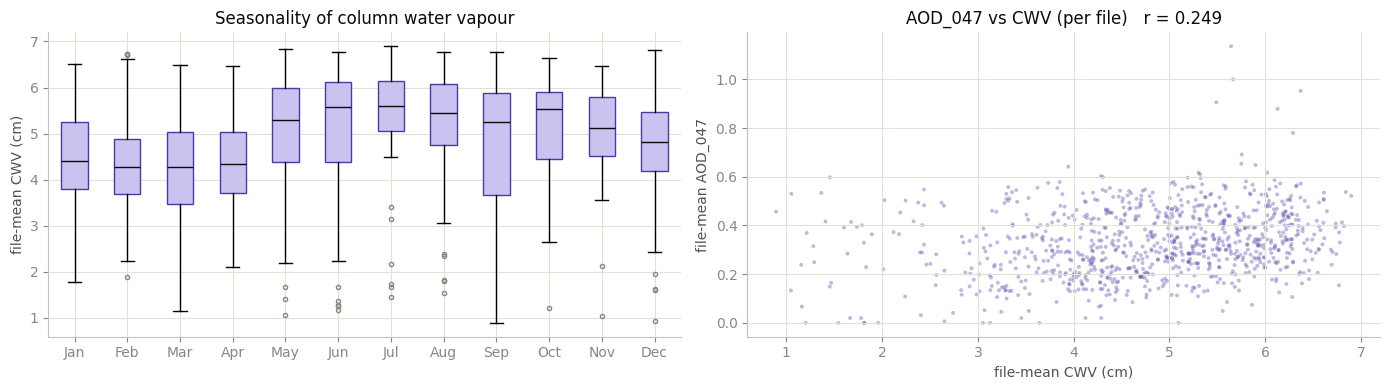

In [14]:
dcw = df[df["CWV_valid_px"] > 0].copy()
dcw["month"] = pd.to_datetime(dcw["date"]).dt.month

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
bp = ax1.boxplot([dcw.loc[dcw["month"] == m, "CWV_mean"].dropna()
                  for m in range(1, 13)],
                 tick_labels=MONTHS, patch_artist=True,
                 medianprops=dict(color=C["ink"]),
                 flierprops=dict(ms=3, markeredgecolor=C["muted"]))
for box in bp["boxes"]:
    box.set(facecolor="#c9c3f0", edgecolor=C["CWV"])
ax1.set_ylabel("file-mean CWV (cm)")
ax1.set_title("Seasonality of column water vapour")

both = df.dropna(subset=["AOD_047_mean", "CWV_mean"])
r = np.corrcoef(both["CWV_mean"], both["AOD_047_mean"])[0, 1]
ax2.scatter(both["CWV_mean"], both["AOD_047_mean"], s=8, alpha=0.35,
            color=C["CWV"], edgecolors="none")
ax2.set_xlabel("file-mean CWV (cm)")
ax2.set_ylabel("file-mean AOD_047")
ax2.set_title(f"AOD_047 vs CWV (per file)   r = {r:.3f}")
plt.tight_layout(); plt.show()

## 14. Dry vs wet season spatial maps

The all-time mean map (section 8) blends two different regimes. Here the
per-month grids are split into dry (Dec–May) and wet (Jun–Nov) composites on a
**shared color scale**, plus their difference on a diverging scale (red = higher
in the dry season). This shows *where* the seasonal AOD change happens, not
just that it happens.

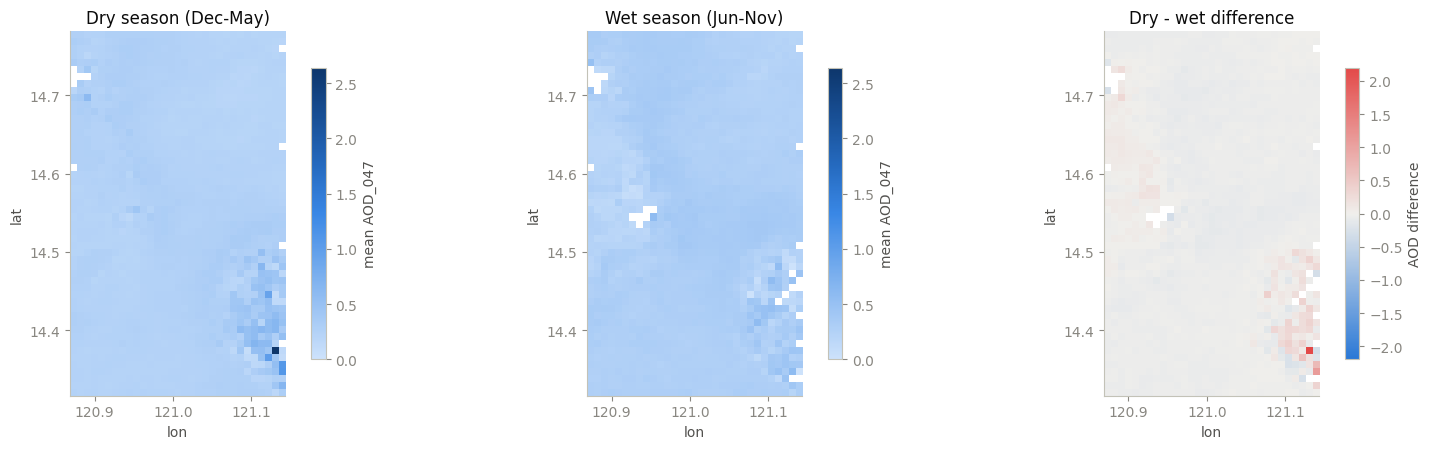

In [15]:
DRY, WET = [12, 1, 2, 3, 4, 5], [6, 7, 8, 9, 10, 11]

def season_mean(month_list):
    idx = [m - 1 for m in month_list]
    s, c = aod_sum[idx].sum(axis=0), aod_cnt[idx].sum(axis=0)
    return np.where(c > 0, s / np.maximum(c, 1), np.nan)

dry_g, wet_g = season_mean(DRY), season_mean(WET)
vmin = np.nanmin([np.nanmin(dry_g), np.nanmin(wet_g)])
vmax = np.nanmax([np.nanmax(dry_g), np.nanmax(wet_g)])
diff = dry_g - wet_g
dmax = np.nanmax(np.abs(diff))
DIV = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, g, cmap, title, kw in [
    (axes[0], dry_g, SEQ_BLUE, "Dry season (Dec-May)", dict(vmin=vmin, vmax=vmax)),
    (axes[1], wet_g, SEQ_BLUE, "Wet season (Jun-Nov)", dict(vmin=vmin, vmax=vmax)),
    (axes[2], diff, DIV, "Dry - wet difference", dict(vmin=-dmax, vmax=dmax)),
]:
    im = ax.imshow(g, cmap=cmap, extent=extent, origin="upper", **kw)
    fig.colorbar(im, ax=ax, shrink=0.8,
                 label="mean AOD_047" if cmap is SEQ_BLUE else "AOD difference")
    ax.set_title(title)
    ax.set_xlabel("lon"); ax.set_ylabel("lat"); ax.grid(False)
plt.tight_layout(); plt.show()

## 15. Data-gap analysis

Days between consecutive dates that have *any* valid AOD. This is what an
application actually feels: median revisit vs worst-case blackout. Long gaps
cluster in the wet season (compare with section 7's coverage-by-month).

Days with valid AOD:  944
Median gap:           1 d   mean: 1.9 d
Gaps > 7 days:        19 (2.0%)
Longest gap:          17 d, ending 2025-11-06


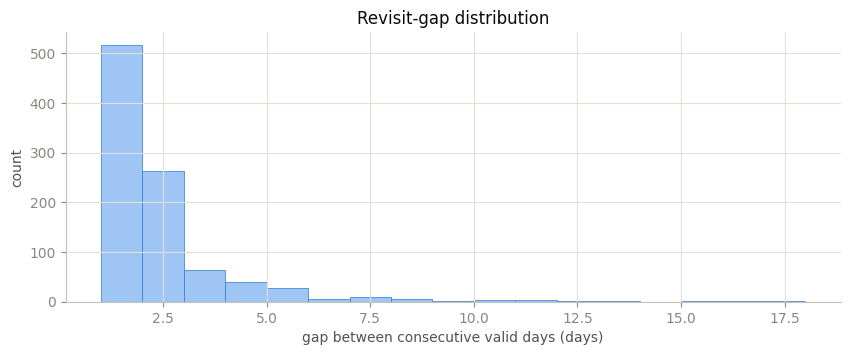

In [16]:
valid_dates = (pd.to_datetime(df.loc[df["AOD_047_valid_px"] > 0, "date"])
                 .sort_values().drop_duplicates())
gaps = valid_dates.diff().dt.days.dropna()
worst_end = valid_dates.iloc[int(gaps.idxmax())] if len(gaps) else None

print(f"Days with valid AOD:  {len(valid_dates)}")
print(f"Median gap:           {gaps.median():.0f} d   mean: {gaps.mean():.1f} d")
print(f"Gaps > 7 days:        {(gaps > 7).sum()} ({(gaps > 7).mean():.1%})")
print(f"Longest gap:          {gaps.max():.0f} d, ending {worst_end:%Y-%m-%d}")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(gaps, bins=range(1, int(gaps.max()) + 2), color="#9ec5f4",
        edgecolor=C["AOD_047"], lw=0.5)
ax.set_xlabel("gap between consecutive valid days (days)")
ax.set_ylabel("count")
ax.set_title("Revisit-gap distribution")
plt.show()